In [2]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings('ignore', message='Unverified HTTPS request')

In [3]:
# =========================================================================
# 📋 STEP 0: FILE ROW COUNT OVERVIEW (WEEK 1)
# =========================================================================

PATH = r'C:\Users\lidon\Desktop\2026spring\IDX_MLS_Analytics'

print("=================== FILE ROW COUNT CHECK ===================")
for file_name in sorted(os.listdir(PATH)):
    if file_name.endswith('.csv'):
        file_path = os.path.join(PATH, file_name)
        try:
            df = pd.read_csv(file_path, low_memory=False)
            print(f"• {file_name:<50} : {len(df):,} rows")
        except Exception as e:
            print(f"❌ Error reading {file_name}: {e}")
print("============================================================\n")

=================== FILE ROW COUNT CHECK ===================
• CRMLSListing202401.csv                             : 27,454 rows
• CRMLSListing202402.csv                             : 27,447 rows
• CRMLSListing202403.csv                             : 32,282 rows
• CRMLSListing202404.csv                             : 36,503 rows
• CRMLSListing202405.csv                             : 38,796 rows
• CRMLSListing202406.csv                             : 35,893 rows
• CRMLSListing202407.csv                             : 36,340 rows
• CRMLSListing202408.csv                             : 35,305 rows
• CRMLSListing202409.csv                             : 34,625 rows
• CRMLSListing202410.csv                             : 34,730 rows
• CRMLSListing202411.csv                             : 25,128 rows
• CRMLSListing202412.csv                             : 19,417 rows
• CRMLSListing202501.csv                             : 37,469 rows
• CRMLSListing202502.csv                             : 33,983 rows
•

In [6]:
# =========================================================================
# ⚙️ DATA QUALITY FUNCTION: PRE-MERGE VALIDATION
# =========================================================================

DATE_FIELDS    = ['CloseDate', 'ListingContractDate',
                  'PurchaseContractDate', 'ContractStatusChangeDate']
NUMERIC_FIELDS = ['ClosePrice', 'ListPrice', 'OriginalListPrice',
                  'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger']
POSTAL_FIELD   = 'PostalCode'
ROW_COUNT_FLOOR = 100


def check_file_quality(file_paths, label):
    """
    Pre-merge validation summarised by check category, not by file.
    Prints one block per check; expands details only when issues exist.
    All files are always returned — nothing is silently dropped.
    """
    if not file_paths:
        print(f"❌ No {label} files found — aborting.")
        return []

    n = len(file_paths)
    print("=" * 60)
    print(f"PRE-MERGE QUALITY CHECK: {label.upper()} FILES ({n} files)")
    print("=" * 60)

    # Baseline columns from the first file
    baseline_cols = set(
        pd.read_csv(file_paths[0], nrows=5, low_memory=False).columns
    )

    # ── Collect results for all three checks ──
    col_issues  = {}   # {filename: {missing, extra}}
    row_issues  = {}   # {filename: [issue strings]}
    fmt_issues  = {}   # {filename: [issue strings]}

    for f_path in file_paths:
        f_name = os.path.basename(f_path)
        try:
            df_head = pd.read_csv(f_path, nrows=5, low_memory=False)
            df_full = pd.read_csv(
                f_path,
                dtype={POSTAL_FIELD: str, 'ListingKey': str},
                low_memory=False
            )

            # CHECK 1: Column Structure
            current_cols = set(df_head.columns)
            missing = baseline_cols - current_cols
            extra   = current_cols  - baseline_cols
            if missing or extra:
                col_issues[f_name] = {'missing': sorted(missing),
                                      'extra':   sorted(extra)}

            # CHECK 2: Row Structure
            r_issues = []
            total_rows = len(df_full)
            dup_rows   = df_full.duplicated().sum()
            if total_rows == 0:
                r_issues.append("Empty file (0 rows)")
            elif total_rows < ROW_COUNT_FLOOR:
                r_issues.append(f"Only {total_rows} rows (threshold: {ROW_COUNT_FLOOR})")
            if dup_rows > 0:
                r_issues.append(f"{dup_rows:,} fully duplicate rows")
            if r_issues:
                row_issues[f_name] = r_issues

            # CHECK 3: Data Format
            f_issues = []
            for col in DATE_FIELDS:
                if col in df_full.columns:
                    sample = df_full[col].dropna().head(50)
                    if len(sample) > 0:
                        try:
                            pd.to_datetime(sample)
                        except Exception:
                            f_issues.append(f"'{col}' cannot be parsed as date")

            for col in NUMERIC_FIELDS:
                if col in df_full.columns:
                    non_num = (
                        pd.to_numeric(df_full[col], errors='coerce').isna().sum()
                        - df_full[col].isna().sum()
                    )
                    if non_num > 0:
                        f_issues.append(f"'{col}' has {non_num:,} non-numeric values")

            if POSTAL_FIELD in df_full.columns:
                bad = df_full[POSTAL_FIELD].dropna()
                bad = bad[~bad.str.match(r'^\d{5}$')]
                if len(bad) > 0:
                    f_issues.append(f"PostalCode: {len(bad):,} values not 5-digit")

            if f_issues:
                fmt_issues[f_name] = f_issues

        except Exception as e:
            row_issues[f_name] = [f"Read error: {str(e)}"]

    # ── Print CHECK 1 ──
    if col_issues:
        print(f"[1] Column Structure  ...  ⚠️  {len(col_issues)} file(s) have column differences")
        for fname, diff in col_issues.items():
            print(f"      • {fname}")
            if diff['missing']:
                print(f"          Missing : {diff['missing']}")
            if diff['extra']:
                print(f"          Extra   : {diff['extra']}")
    else:
        print(f"[1] Column Structure  ...  ✅  All {n} files passed")

    # ── Print CHECK 2 ──
    if row_issues:
        print(f"[2] Row Structure     ...  ⚠️  {len(row_issues)} file(s) flagged")
        for fname, issues in row_issues.items():
            for iss in issues:
                print(f"      • {fname}   {iss}")
    else:
        print(f"[2] Row Structure     ...  ✅  All {n} files passed")

    # ── Print CHECK 3 ──
    if fmt_issues:
        print(f"[3] Data Format       ...  ⚠️  {len(fmt_issues)} file(s) flagged")
        for fname, issues in fmt_issues.items():
            for iss in issues:
                print(f"      • {fname}   {iss}")
    else:
        print(f"[3] Data Format       ...  ✅  All {n} files passed")

    # ── Summary line ──
    all_flagged = set(col_issues) | set(row_issues) | set(fmt_issues)
    n_clean     = n - len(all_flagged)
    print(f"\nRESULT: {n_clean} clean / {len(all_flagged)} flagged "
          f"— all {n} files included in merge")
    print("=" * 60 + "\n")

    return file_paths

In [7]:
# =========================================================================
# 🚀 MAIN DATA PIPELINE
# =========================================================================

PATH = r'C:\Users\lidon\Desktop\2026spring\IDX_MLS_Analytics'

sold_files    = sorted(glob.glob(os.path.join(PATH, 'CRMLSSold*.csv')))
listing_files = sorted(glob.glob(os.path.join(PATH, 'CRMLSListing*.csv')))

# -------------------------------------------------------------------------
# 1. Sold Data Quality Validation & Processing
# -------------------------------------------------------------------------
safe_sold_files = check_file_quality(sold_files, label='Sold')

sold_list = []
for f in safe_sold_files:
    df = pd.read_csv(
        f,
        dtype={POSTAL_FIELD: str, 'ListingKey': str},
        low_memory=False
    )
    sold_list.append(df)

if sold_list:
    combined_sold      = pd.concat(sold_list, ignore_index=True, join='outer')
    sold_before_filter = len(combined_sold)
    combined_sold      = combined_sold[combined_sold['PropertyType'] == 'Residential']
    sold_after_filter  = len(combined_sold)
else:
    combined_sold = pd.DataFrame()
    sold_before_filter = sold_after_filter = 0

# -------------------------------------------------------------------------
# 2. Listing Data Quality Validation & Processing
# -------------------------------------------------------------------------
safe_listing_files = check_file_quality(listing_files, label='Listing')

listing_list = []
for f in safe_listing_files:
    df = pd.read_csv(
        f,
        dtype={POSTAL_FIELD: str, 'ListingKey': str},
        low_memory=False
    )
    listing_list.append(df)

if listing_list:
    combined_listings      = pd.concat(listing_list, ignore_index=True, join='outer')
    listings_before_filter = len(combined_listings)
    combined_listings      = combined_listings[combined_listings['PropertyType'] == 'Residential']
    listings_after_filter  = len(combined_listings)
else:
    combined_listings = pd.DataFrame()
    listings_before_filter = listings_after_filter = 0

# -------------------------------------------------------------------------
# 3. Output
# -------------------------------------------------------------------------
combined_sold.to_csv(
    os.path.join(PATH, 'all_sold_residential.csv'), index=False, encoding='utf-8'
)
combined_listings.to_csv(
    os.path.join(PATH, 'all_listings_residential.csv'), index=False, encoding='utf-8'
)

# -------------------------------------------------------------------------
# 4. Final Verification Report
# -------------------------------------------------------------------------
print("=================== IDX PIPELINE EXECUTION LOG ===================")
print(f"  Sold    files processed    : {len(safe_sold_files)}")
print(f"  Listing files processed    : {len(safe_listing_files)}")
print(f"  Sold    rows before filter : {sold_before_filter:,}")
print(f"  Sold    rows after  filter : {sold_after_filter:,}")
print(f"  Sold    rows removed       : {sold_before_filter - sold_after_filter:,}")
print(f"  Listing rows before filter : {listings_before_filter:,}")
print(f"  Listing rows after  filter : {listings_after_filter:,}")
print(f"  Listing rows removed       : {listings_before_filter - listings_after_filter:,}")
print("==================================================================")

PRE-MERGE QUALITY CHECK: SOLD FILES (29 files)
[1] Column Structure  ...  ⚠️  25 file(s) have column differences
      • CRMLSSold202402.csv
          Missing : ['BuyerAgentAOR', 'ListAgentAOR', 'OriginatingSystemName', 'OriginatingSystemSubName']
          Extra   : ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']
      • CRMLSSold202403.csv
          Missing : ['BuyerAgentAOR', 'ListAgentAOR', 'OriginatingSystemName', 'OriginatingSystemSubName']
          Extra   : ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'latfilled', 'lonfilled']
      • CRMLSSold202404.csv
          Missing : ['BuyerAgentAOR', 'ListAgentAOR', 'OriginatingSystemName', 'OriginatingSystemSubName']
          Extra   : ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'latfilled', 'lonfilled']
      • CRMLSSold202405.csv
          Missing : ['OriginatingSystemName', 'OriginatingSystemSubName']
          Extra   : ['latfilled', 'lonfilled']
      • CRMLSSold202406.csv
          Missin

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

# =========================================================================
# Configuration(WEEK 2)
# =========================================================================

PATH = r'C:\Users\lidon\Desktop\2026spring\IDX_MLS_Analytics'

SOLD_CSV    = os.path.join(PATH, 'all_sold_residential.csv')
LISTING_CSV = os.path.join(PATH, 'all_listings_residential.csv')
CHART_DIR   = os.path.join(PATH, 'eda_charts')
os.makedirs(CHART_DIR, exist_ok=True)

DTYPE_SPEC = {'PostalCode': str, 'ListingKey': str}

# =========================================================================
# Load datasets
# =========================================================================

print("Loading combined datasets...")
sold     = pd.read_csv(SOLD_CSV,    dtype=DTYPE_SPEC, low_memory=False)
listings = pd.read_csv(LISTING_CSV, dtype=DTYPE_SPEC, low_memory=False)
print(f"  all_sold     : {len(sold):,} rows loaded")
print(f"  all_listings : {len(listings):,} rows loaded\n")

Loading combined datasets...
  all_sold     : 430,447 rows loaded
  all_listings : 594,825 rows loaded



In [9]:
# =========================================================================
# TASK 1 — Validate Structure
# =========================================================================

print("=" * 65)
print("TASK 1 — STRUCTURE VALIDATION")
print("=" * 65)

for label, df in [('all_sold', sold), ('all_listings', listings)]:
    print(f"\n── {label} ──")
    print(f"  Row count    : {df.shape[0]:,}")
    print(f"  Column count : {df.shape[1]}")
    print(f"\n  Column names and data types:")
    dtype_df = df.dtypes.reset_index()
    dtype_df.columns = ['Column', 'DType']
    for _, row in dtype_df.iterrows():
        print(f"    {row['Column']:<45} {str(row['DType'])}")

TASK 1 — STRUCTURE VALIDATION

── all_sold ──
  Row count    : 430,447
  Column count : 84

  Column names and data types:
    BuyerAgentAOR                                 object
    ListAgentAOR                                  object
    Flooring                                      object
    ViewYN                                        object
    WaterfrontYN                                  object
    BasementYN                                    object
    PoolPrivateYN                                 object
    OriginalListPrice                             float64
    ListingKey                                    object
    ListAgentEmail                                object
    CloseDate                                     object
    ClosePrice                                    float64
    ListAgentFirstName                            object
    ListAgentLastName                             object
    Latitude                                      float64
    Longitude      

In [10]:
# =========================================================================
# TASK 2 — High Missing Values (> 90%)
# =========================================================================

print("\n" + "=" * 65)
print("TASK 2 — HIGH MISSING VALUE COLUMNS (> 90% null)")
print("=" * 65)

for label, df in [('all_sold', sold), ('all_listings', listings)]:
    total = len(df)
    missing = (df.isnull().sum() / total * 100).sort_values(ascending=False)
    zombie_cols = missing[missing > 90]

    print(f"\n── {label} ── ({len(zombie_cols)} zombie columns found)")
    if len(zombie_cols) > 0:
        print(f"  {'Column':<45} {'Missing %':>10}  {'Missing Count':>15}")
        print(f"  {'-'*45} {'-'*10}  {'-'*15}")
        for col, pct in zombie_cols.items():
            count = df[col].isnull().sum()
            print(f"  {col:<45} {pct:>9.1f}%  {count:>15,}")
    else:
        print("  No columns above 90% missing threshold.")



TASK 2 — HIGH MISSING VALUE COLUMNS (> 90% null)

── all_sold ── (15 zombie columns found)
  Column                                         Missing %    Missing Count
  --------------------------------------------- ----------  ---------------
  TaxYear                                           100.0%          430,447
  FireplacesTotal                                   100.0%          430,447
  TaxAnnualAmount                                   100.0%          430,447
  AboveGradeFinishedArea                            100.0%          430,447
  ElementarySchoolDistrict                          100.0%          430,447
  BusinessType                                      100.0%          430,447
  CoveredSpaces                                     100.0%          430,447
  MiddleOrJuniorSchoolDistrict                      100.0%          430,447
  WaterfrontYN                                       99.9%          430,176
  BelowGradeFinishedArea                             99.4%          427,

In [11]:
# =========================================================================
# TASK 3 — Fields Classification
# =========================================================================

print("\n" + "=" * 65)
print("TASK 3 — FIELDS CLASSIFICATION")
print("=" * 65)

MARKET_FIELDS = [
    # Price
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    # Property characteristics
    'LivingArea', 'BuildingAreaTotal', 'AboveGradeFinishedArea',
    'BelowGradeFinishedArea', 'LotSizeArea', 'LotSizeAcres',
    'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
    'MainLevelBedrooms', 'YearBuilt', 'NewConstructionYN',
    'PropertyType', 'PropertySubType',
    # Garage / parking
    'GarageSpaces', 'AttachedGarageYN', 'ParkingTotal', 'CoveredSpaces',
    # Amenities
    'FireplacesTotal', 'FireplaceYN', 'Stories', 'Levels',
    'PoolPrivateYN', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'Flooring',
    # Fees
    'AssociationFee', 'AssociationFeeFrequency',
    'TaxAnnualAmount', 'TaxYear',
    # Market timing
    'DaysOnMarket', 'ListingContractDate', 'PurchaseContractDate',
    'ContractStatusChangeDate', 'CloseDate', 'MlsStatus',
    # Location
    'UnparsedAddress', 'StreetNumberNumeric', 'City',
    'StateOrProvince', 'PostalCode', 'CountyOrParish',
    'MLSAreaMajor', 'SubdivisionName', 'Latitude', 'Longitude',
    # School districts
    'ElementarySchool', 'ElementarySchoolDistrict',
    'MiddleOrJuniorSchool', 'MiddleOrJuniorSchoolDistrict',
    'HighSchool', 'HighSchoolDistrict',
]

METADATA_FIELDS = [
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    'OriginatingSystemName', 'OriginatingSystemSubName',
    'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName',
    'ListAgentEmail', 'ListAgentAOR',
    'CoListAgentFirstName', 'CoListAgentLastName',
    'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
    'BuyerAgentAOR', 'CoBuyerAgentFirstName',
    'ListOfficeName', 'CoListOfficeName',
    'BuyerOfficeName', 'BuyerOfficeAOR',
    'BuilderName', 'BusinessType', 'LotSizeDimensions',
]

all_cols     = set(sold.columns)
classified   = set(MARKET_FIELDS) | set(METADATA_FIELDS)
unclassified = all_cols - classified

print(f"\n  Market Analysis Fields  : {len([c for c in MARKET_FIELDS if c in all_cols])}")
print(f"  Metadata Fields         : {len([c for c in METADATA_FIELDS if c in all_cols])}")
if unclassified:
    print(f"  Unclassified (review)   : {len(unclassified)}")
    for col in sorted(unclassified):
        print(f"    • {col}")

print("\n  Market Analysis Fields:")
for col in MARKET_FIELDS:
    marker = "✅" if col in all_cols else "⬜ (not in sold)"
    print(f"    {marker}  {col}")

print("\n  Metadata Fields:")
for col in METADATA_FIELDS:
    marker = "✅" if col in all_cols else "⬜ (not in sold)"
    print(f"    {marker}  {col}")


TASK 3 — FIELDS CLASSIFICATION

  Market Analysis Fields  : 56
  Metadata Fields         : 24
  Unclassified (review)   : 4
    • BuyerAgencyCompensation
    • BuyerAgencyCompensationType
    • latfilled
    • lonfilled

  Market Analysis Fields:
    ✅  ClosePrice
    ✅  ListPrice
    ✅  OriginalListPrice
    ✅  LivingArea
    ✅  BuildingAreaTotal
    ✅  AboveGradeFinishedArea
    ✅  BelowGradeFinishedArea
    ✅  LotSizeArea
    ✅  LotSizeAcres
    ✅  LotSizeSquareFeet
    ✅  BedroomsTotal
    ✅  BathroomsTotalInteger
    ✅  MainLevelBedrooms
    ✅  YearBuilt
    ✅  NewConstructionYN
    ✅  PropertyType
    ✅  PropertySubType
    ✅  GarageSpaces
    ✅  AttachedGarageYN
    ✅  ParkingTotal
    ✅  CoveredSpaces
    ✅  FireplacesTotal
    ✅  FireplaceYN
    ✅  Stories
    ✅  Levels
    ✅  PoolPrivateYN
    ✅  ViewYN
    ✅  WaterfrontYN
    ✅  BasementYN
    ✅  Flooring
    ✅  AssociationFee
    ✅  AssociationFeeFrequency
    ✅  TaxAnnualAmount
    ✅  TaxYear
    ✅  DaysOnMarket
    ✅  Li

In [12]:
# =========================================================================
# TASK 4 — Numerical Distributions (8 key fields)
# =========================================================================

print("\n" + "=" * 65)
print("TASK 4 — NUMERICAL DISTRIBUTIONS (8 KEY FIELDS)")
print("=" * 65)

KEY_FIELDS = [
    'ClosePrice', 'ListPrice', 'LivingArea', 'LotSizeAcres',
    'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt'
]

for label, df in [('all_sold', sold), ('all_listings', listings)]:
    available = [c for c in KEY_FIELDS if c in df.columns]
    desc = df[available].describe(percentiles=[.25, .5, .75, .95]).T
    desc = desc[['count', 'min', '25%', '50%', 'mean', '75%', '95%', 'max']]
    desc['count'] = desc['count'].astype(int)
    print(f"\n── {label} ──")
    print(desc.to_string(float_format=lambda x: f"{x:,.1f}"))


TASK 4 — NUMERICAL DISTRIBUTIONS (8 KEY FIELDS)

── all_sold ──
                        count     min       25%       50%        mean         75%         95%           max
ClosePrice             430445     0.0 575,000.0 825,000.0 1,193,113.2 1,300,000.0 2,850,000.0 989,500,000.0
ListPrice              430447   525.0 578,000.0 819,000.0 1,141,744.1 1,295,000.0 2,860,000.0 137,500,000.0
LivingArea             430202     0.0   1,248.0   1,644.0     1,904.1     2,221.0     3,562.0  17,021,321.0
LotSizeAcres           396793     0.0       0.1       0.2        64.0         0.3         2.8   7,810,698.4
BedroomsTotal          430435     0.0       3.0       3.0         3.2         4.0         5.0          45.0
BathroomsTotalInteger  430377     0.0       2.0       2.0         2.5         3.0         4.0         175.0
DaysOnMarket           430447  -288.0       8.0      18.0        37.3        48.0       132.0      12,430.0
YearBuilt              430065 1,776.0   1,960.0   1,979.0     1,978.6  


TASK 5 — EDA CHARTS
  Q2 — Median ClosePrice : $825,000
  Q2 — Mean   ClosePrice : $1,193,113
  Q3 — Median DOM : 18 days
  Q3 — Mean   DOM : 37.3 days
  Q4 — Above list : 172,617  (40.1%)
  Q4 — At list    : 74,731  (17.4%)
  Q4 — Below list : 183,097  (42.5%)
  Q5 — Close before Listing : 65 records
  Q5 — Close before Contract : 241 records
  Q5 — Contract before Listing : 280 records

  Q6 — Top 5 counties by median close price:
    Del Norte                      $2,485,000
    Other County                   $2,462,500
    San Mateo                      $1,700,000
    Santa Clara                    $1,600,000
    San Francisco                  $1,199,950


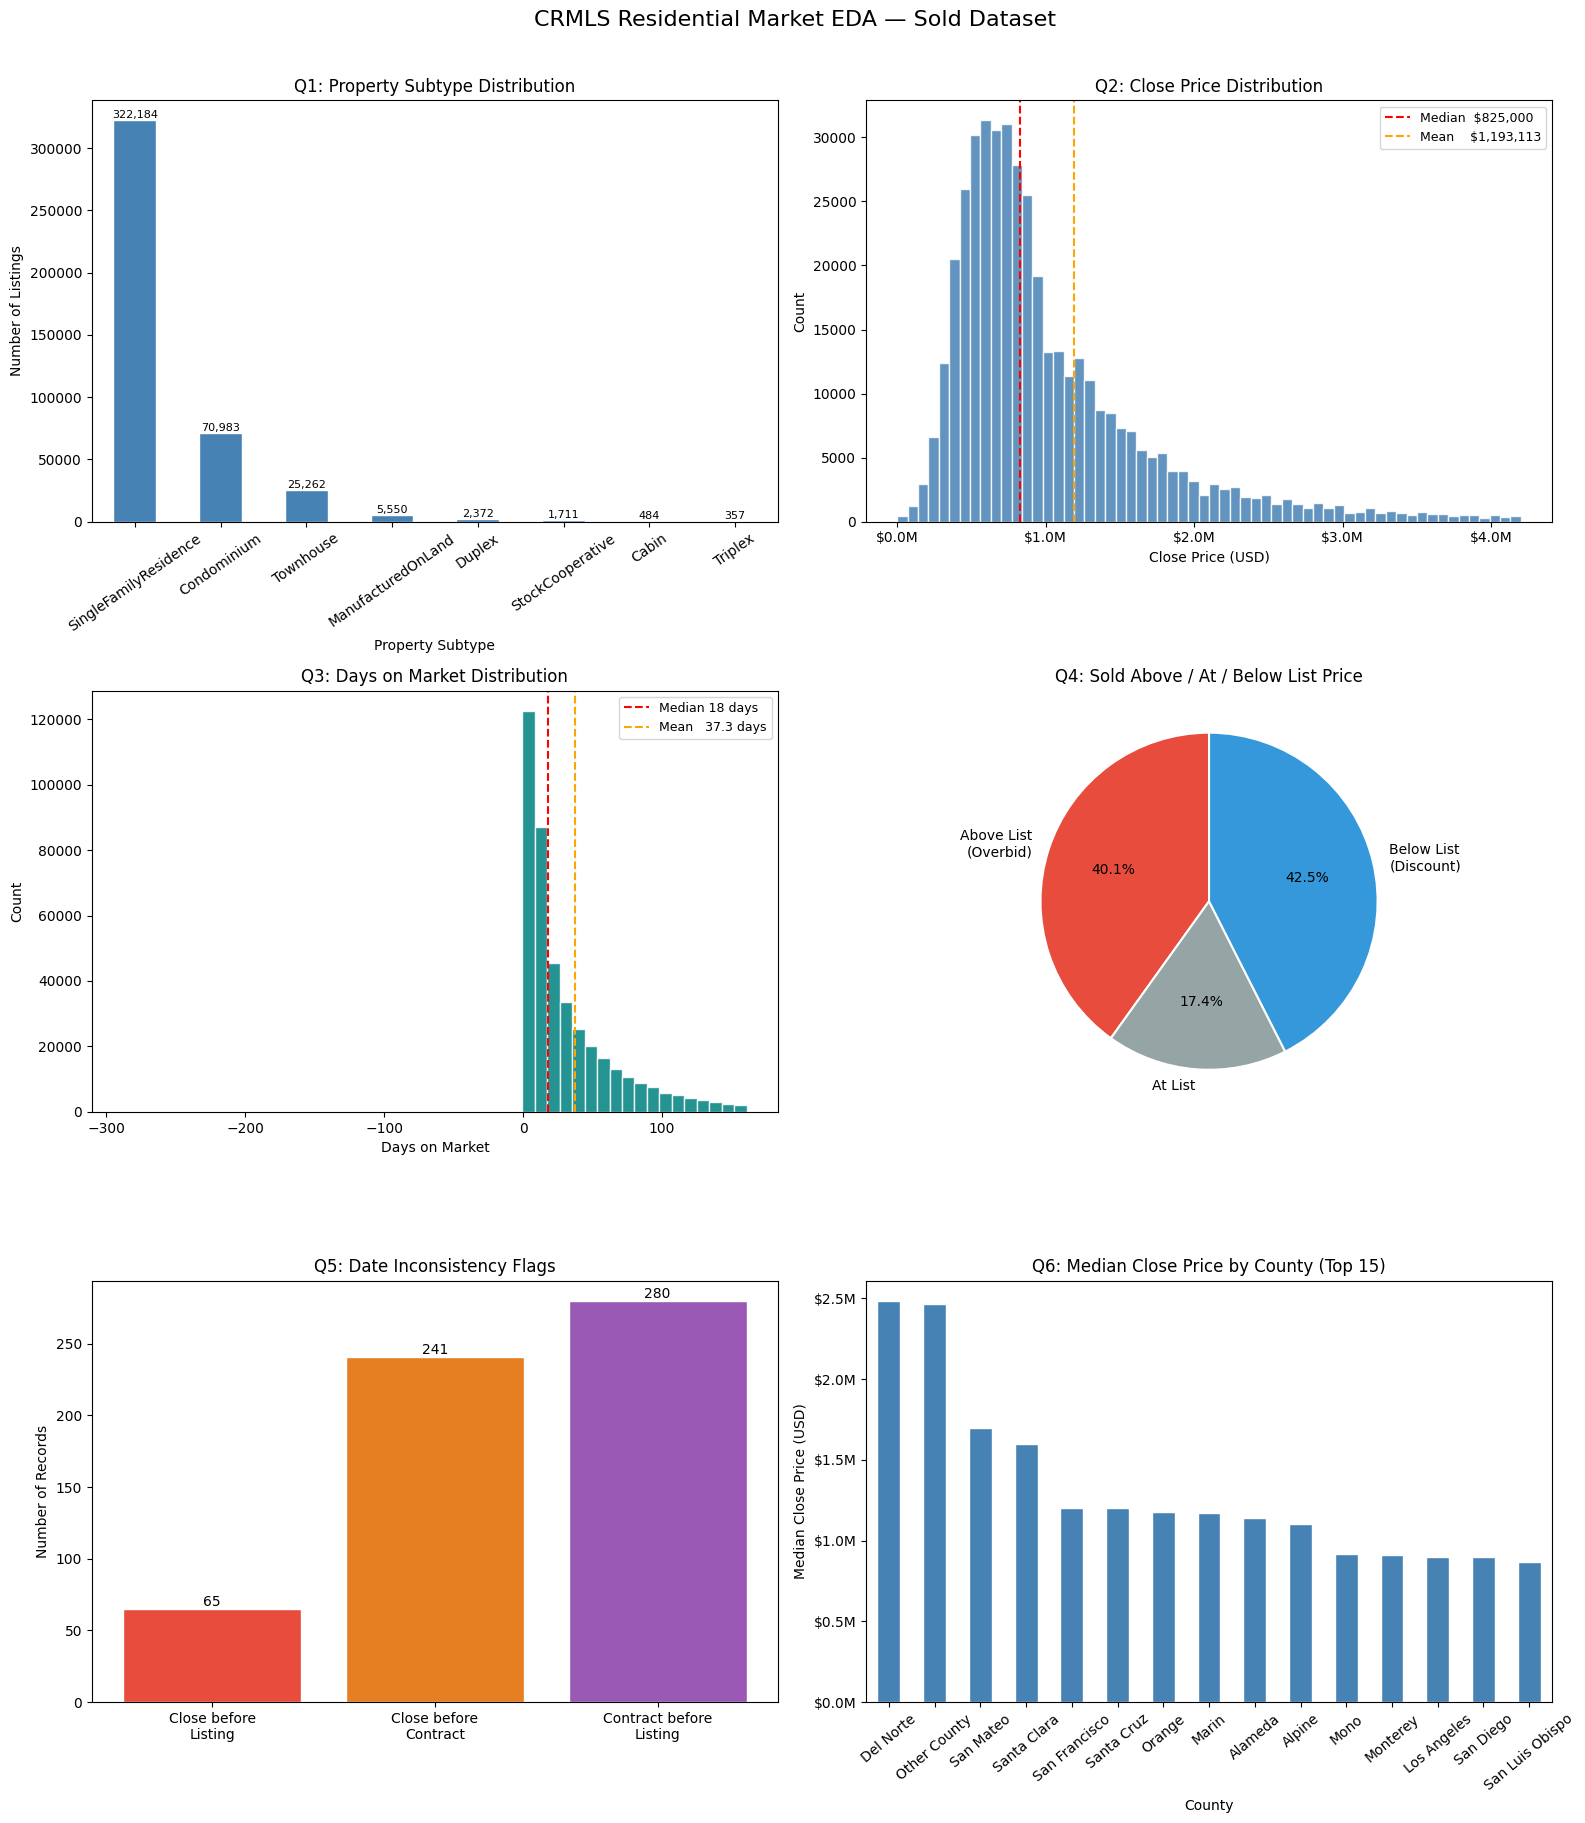

In [14]:
# =========================================================================
# TASK 5 — EDA Charts (6 business questions)
# =========================================================================

print("\n" + "=" * 65)
print("TASK 5 — EDA CHARTS")
print("=" * 65)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('CRMLS Residential Market EDA — Sold Dataset', fontsize=16, y=1.01)

# ── Q1: Property subtype share ──────────────────────────────────────────
ax = axes[0, 0]
subtype_counts = sold['PropertySubType'].value_counts().head(8)
subtype_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Q1: Property Subtype Distribution')
ax.set_xlabel('Property Subtype')
ax.set_ylabel('Number of Listings')
ax.tick_params(axis='x', rotation=35)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

# ── Q2: ClosePrice distribution — median vs mean ────────────────────────
ax = axes[0, 1]
prices         = sold['ClosePrice'].dropna()
prices_clipped = prices[prices <= prices.quantile(0.98)]  # clip top 2% for readability
ax.hist(prices_clipped, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(prices.median(), color='red',    linestyle='--', linewidth=1.5,
           label=f'Median  ${prices.median():,.0f}')
ax.axvline(prices.mean(),   color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean    ${prices.mean():,.0f}')
ax.set_title('Q2: Close Price Distribution')
ax.set_xlabel('Close Price (USD)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(fontsize=9)
print(f"  Q2 — Median ClosePrice : ${prices.median():,.0f}")
print(f"  Q2 — Mean   ClosePrice : ${prices.mean():,.0f}")

# ── Q3: Days on Market distribution ─────────────────────────────────────
ax = axes[1, 0]
dom         = sold['DaysOnMarket'].dropna()
dom_clipped = dom[dom <= dom.quantile(0.97)]
ax.hist(dom_clipped, bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(dom.median(), color='red',    linestyle='--', linewidth=1.5,
           label=f'Median {dom.median():.0f} days')
ax.axvline(dom.mean(),   color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean   {dom.mean():.1f} days')
ax.set_title('Q3: Days on Market Distribution')
ax.set_xlabel('Days on Market')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
print(f"  Q3 — Median DOM : {dom.median():.0f} days")
print(f"  Q3 — Mean   DOM : {dom.mean():.1f} days")

# ── Q4: Sold above vs below list price ──────────────────────────────────
ax    = axes[1, 1]
valid = sold[['ClosePrice', 'ListPrice']].dropna()
above = (valid['ClosePrice'] >  valid['ListPrice']).sum()
at    = (valid['ClosePrice'] == valid['ListPrice']).sum()
below = (valid['ClosePrice'] <  valid['ListPrice']).sum()
labels = ['Above List\n(Overbid)', 'At List', 'Below List\n(Discount)']
sizes  = [above, at, below]
colors = ['#e74c3c', '#95a5a6', '#3498db']
ax.pie(sizes, labels=labels, colors=colors,
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Q4: Sold Above / At / Below List Price')
print(f"  Q4 — Above list : {above:,}  ({above/len(valid)*100:.1f}%)")
print(f"  Q4 — At list    : {at:,}  ({at/len(valid)*100:.1f}%)")
print(f"  Q4 — Below list : {below:,}  ({below/len(valid)*100:.1f}%)")

# ── Q5: Date inconsistency flags ─────────────────────────────────────────
ax = axes[2, 0]
s  = sold.copy()
for col in ['ListingContractDate', 'PurchaseContractDate', 'CloseDate']:
    if col in s.columns:
        s[col] = pd.to_datetime(s[col], errors='coerce')

flag_counts = {}
if 'ListingContractDate' in s.columns and 'CloseDate' in s.columns:
    flag_counts['Close before\nListing'] = (
        s['CloseDate'] < s['ListingContractDate']
    ).sum()
if 'PurchaseContractDate' in s.columns and 'CloseDate' in s.columns:
    flag_counts['Close before\nContract'] = (
        s['CloseDate'] < s['PurchaseContractDate']
    ).sum()
if 'ListingContractDate' in s.columns and 'PurchaseContractDate' in s.columns:
    flag_counts['Contract before\nListing'] = (
        s['PurchaseContractDate'] < s['ListingContractDate']
    ).sum()

if flag_counts:
    bars = ax.bar(flag_counts.keys(), flag_counts.values(),
                  color=['#e74c3c', '#e67e22', '#9b59b6'], edgecolor='white')
    ax.set_title('Q5: Date Inconsistency Flags')
    ax.set_ylabel('Number of Records')
    for bar in bars:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)
    for flag, count in flag_counts.items():
        print(f"  Q5 — {flag.replace(chr(10), ' ')} : {count:,} records")
else:
    ax.text(0.5, 0.5, 'Date columns not available',
            ha='center', va='center', transform=ax.transAxes)

# ── Q6: Median close price by county (top 15) ───────────────────────────
ax = axes[2, 1]
if 'CountyOrParish' in sold.columns:
    county_median = (
        sold.groupby('CountyOrParish')['ClosePrice']
        .median()
        .sort_values(ascending=False)
        .head(15)
    )
    county_median.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Q6: Median Close Price by County (Top 15)')
    ax.set_xlabel('County')
    ax.set_ylabel('Median Close Price (USD)')
    ax.tick_params(axis='x', rotation=40)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
    )
    print(f"\n  Q6 — Top 5 counties by median close price:")
    for county, price in county_median.head(5).items():
        print(f"    {county:<30} ${price:,.0f}")

plt.tight_layout()
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()